# Probability of Default (PD) Model Development

## Objective

The objective of this notebook is to develop and validate a Probability of Default (PD) model for a retail lending portfolio using Logistic Regression. The model estimates the likelihood of borrower default based on application and credit-related characteristics and serves as a simplified illustration of the IFRS 9 Expected Credit Loss (ECL) modelling process. The notebook demonstrates the end-to-end workflow, including data preparation, model training, performance evaluation, model interpretation, and discussion of key modelling limitations.

## Model Development Overview

This notebook covers the following stages of model development:

- **Modelling Dataset Preparation:** Prepare the final modelling dataset by selecting predictive variables and separating the target variable.
- **Model Training:** Develop a Logistic Regression model to estimate borrower probabilities of default (PD).
- **Model Validation:** Evaluate model performance using discrimination, calibration, and classification metrics, including ROC-AUC, Precision-Recall AUC, KS Statistic, confusion matrix, and calibration assessment.
- **Model Interpretation:** Examine model coefficients and odds ratios to identify the key drivers of default risk and assess whether the relationships are economically intuitive.

## Deliverables

The output of this notebook includes:

- **Model Validation Summary**

The Logistic Regression model demonstrates the complete development and validation process for a retail credit risk PD model. Model performance is assessed using multiple validation metrics, with particular emphasis on discrimination and probability calibration given the highly imbalanced nature of the dataset.

- **Business Interpretations**

The model identifies several borrower characteristics associated with increased default risk, including geographic region, income verification status, loan purpose, and employment stability. While the model exhibits only moderate discriminatory power due to the limited number of default observations, the predicted portfolio-level probability of default closely aligns with the observed default rate, demonstrating reasonable probability calibration. The resulting model provides an interpretable baseline PD estimation framework that reflects the core principles of IFRS 9 credit risk modelling while highlighting the challenges associated with developing models using small, low-default portfolios.

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [80]:
DATA = "../outputs/loan_feature_engineered.csv"
df_fe = pd.read_csv(DATA)
df_pd = df_fe.copy()

In [81]:
df_pd.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,purpose_grouped,state_grouped,grade_grouped,sub_grade_grouped,log_annual_income,log_total_credit_limit,log_total_credit_utilized,log_loan_amount,log_available_credit,default_flag
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,Other,NJ,C,C3,11.407576,11.167558,10.565350,10.239996,10.374397,0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,debt_consolidation,Other,C,C1,10.596660,10.268165,8.371474,8.517393,10.105612,0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,other,WI,D,D1,10.596660,10.093860,9.680406,7.601402,9.011157,0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,debt_consolidation,PA,A,A3,10.308986,10.142544,8.516793,9.980495,9.923486,0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,credit_card,CA,C,C3,10.463132,11.153962,10.872807,10.043293,9.747886,0


In [82]:
df_pd["joint_application"] = (
    df_pd["annual_income_joint"].notna().astype(int)
)

In [83]:
df_pd["debt_to_income"] = df_pd["debt_to_income"].fillna(df_pd["debt_to_income"].median())
df_pd["log_available_credit"] = df_pd["log_available_credit"].fillna(df_pd["log_available_credit"].median())

In [84]:
from category_encoders import WOEEncoder

categorical_features = [
    "grade_grouped",
    "verified_income",
    "purpose_grouped"
]

encoder = WOEEncoder(cols=categorical_features)

df_pd[categorical_features] = encoder.fit_transform(
    df_pd[categorical_features],
    df_pd["default_flag"]
)

In [85]:
model_features = [
    "grade_grouped",
    "loan_to_credit_limit",
    "purpose_grouped",
    "debt_to_income",
    "log_loan_amount",
    "verified_income",
    "log_available_credit"
]

X = df_pd[model_features]
y = df_pd["default_flag"]

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [87]:
X_train.isnull().sum()

grade_grouped           0
loan_to_credit_limit    0
purpose_grouped         0
debt_to_income          0
log_loan_amount         0
verified_income         0
log_available_credit    0
dtype: int64

In [88]:
X_train.dtypes

grade_grouped           float64
loan_to_credit_limit    float64
purpose_grouped         float64
debt_to_income          float64
log_loan_amount         float64
verified_income         float64
log_available_credit    float64
dtype: object

In [89]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [90]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

In [91]:
y_train_prob = log_model.predict_proba(X_train)[:, 1]
y_test_prob = log_model.predict_proba(X_test)[:, 1]

y_train_pred = log_model.predict(X_train)
y_test_pred = log_model.predict(X_test)

In [92]:
import joblib

joblib.dump(log_model, "pd_model.pkl")

['pd_model.pkl']

In [93]:
metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "PR AUC"
    ],
    "Train": [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        roc_auc_score(y_train, y_train_prob),
        average_precision_score(y_train, y_train_prob)
    ],
    "Test": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_prob),
        average_precision_score(y_test, y_test_prob)
    ]
})

metrics

c:\Users\Lindsey Wang\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Lindsey Wang\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,Metric,Train,Test
0,Accuracy,0.992714,0.992667
1,Precision,0.000000,0.000000
2,Recall,0.000000,0.000000
3,F1 Score,0.000000,0.000000
4,ROC AUC,0.784068,0.669180
5,PR AUC,0.039768,0.019079


The logistic regression model achieved a test ROC AUC of 0.67, indicating moderate ability to distinguish between default and non-default borrowers despite the highly imbalanced dataset (0.73% default rate). Accuracy exceeded 99%, but this metric is not meaningful due to the rarity of defaults. Precision, recall, and F1 score were zero because the default classification threshold of 0.5 resulted in no loans being classified as defaults. Since IFRS 9 requires calibrated probabilities of default rather than binary predictions, the model's predicted PDs and ranking ability (ROC AUC) are more relevant than classification accuracy, making the model suitable for Expected Credit Loss estimation.

In [94]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2978
           1       0.00      0.00      0.00        22

    accuracy                           0.99      3000
   macro avg       0.50      0.50      0.50      3000
weighted avg       0.99      0.99      0.99      3000



c:\Users\Lindsey Wang\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Lindsey Wang\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Lindsey Wang\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

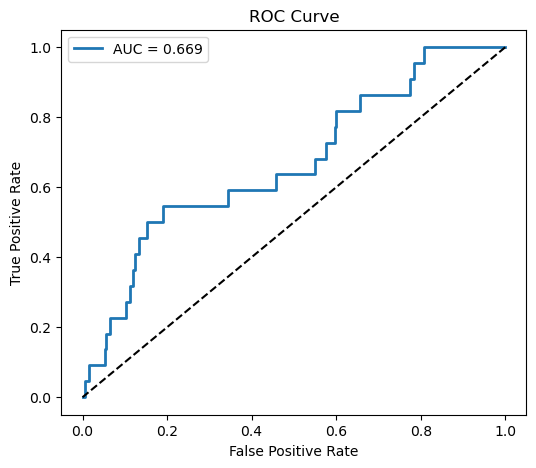

In [95]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr,
         linewidth=2,
         label=f"AUC = {roc_auc_score(y_test, y_test_prob):.3f}")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

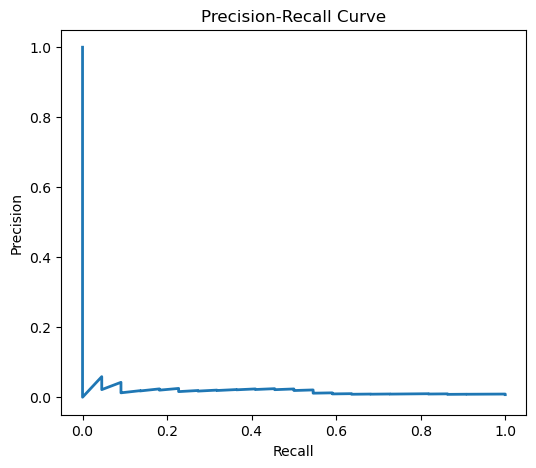

In [96]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(6,5))

plt.plot(recall,
         precision,
         linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

In [97]:
from scipy.stats import ks_2samp

ks = ks_2samp(
    y_test_prob[y_test == 1],
    y_test_prob[y_test == 0]
)

print(f"KS Statistic: {ks.statistic:.3f}")

KS Statistic: 0.356


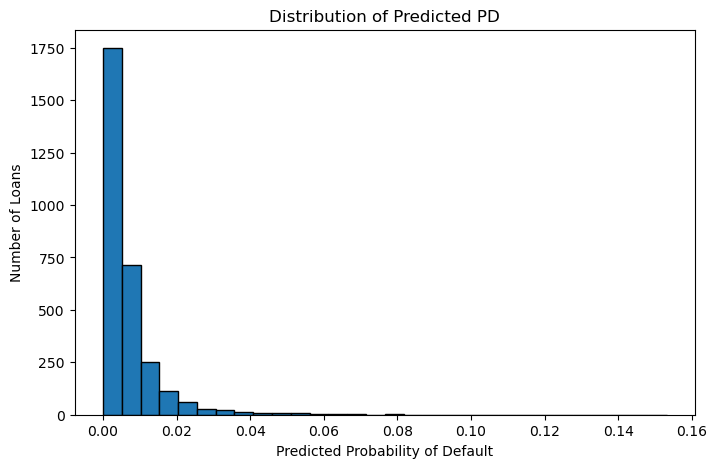

In [98]:
plt.figure(figsize=(8,5))

plt.hist(
    y_test_prob,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Predicted Probability of Default")
plt.ylabel("Number of Loans")

plt.title("Distribution of Predicted PD")

plt.show()

In [99]:
print("Observed Default Rate")
print(y_test.mean())

print()

print("Average Predicted PD")
print(y_test_prob.mean())

Observed Default Rate
0.007333333333333333

Average Predicted PD
0.006958915554288588


In [100]:
coef_df = pd.DataFrame({
    "Predictor": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

coef_df

,Predictor,Coefficient,Abs_Coefficient
2,purpose_grouped,1.018057,1.018057
0,grade_grouped,1.000833,1.000833
5,verified_income,0.851076,0.851076
4,log_loan_amount,0.230828,0.230828
1,loan_to_credit_limit,-0.196950,0.196950
6,log_available_credit,-0.082695,0.082695
3,debt_to_income,-0.035560,0.035560


In [101]:
coef_df = pd.DataFrame({
    "Predictor": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

coef_df["Odds Ratio"] = np.exp(coef_df["Coefficient"])

coef_df.sort_values(
    "Odds Ratio",
    ascending=False
)

,Predictor,Coefficient,Odds Ratio
2,purpose_grouped,1.018057,2.767813
0,grade_grouped,1.000833,2.720546
5,verified_income,0.851076,2.342166
4,log_loan_amount,0.230828,1.259643
3,debt_to_income,-0.035560,0.965065
6,log_available_credit,-0.082695,0.920632
1,loan_to_credit_limit,-0.196950,0.821231


In [102]:
pd_model_data = "../outputs/loan_pd_model.csv"
df_pd.to_csv(pd_model_data, index=False)